<a href="https://colab.research.google.com/github/Atif-Azmi/Machine-Learning/blob/main/Lab_Work_A4_B4_54.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib as plt

In [10]:
#importing dataset
dataframe_train=pd.read_csv('/content/titanic.csv')

In [16]:
#data EDA
dataframe_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [18]:
dataframe_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [22]:
dataframe_train.shape

(891, 12)

In [24]:
dataframe_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [27]:
dataframe_train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [29]:
dataframe_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [31]:
dataframe_train.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [33]:
dataframe_train['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [34]:
def age_approach(cols):
    Age = cols[0]
    PClass = cols[1]
    if pd.isnull(Age):
        if PClass == 1:
            return 39
        elif PClass == 2:
            return 30
        else:
            return 24
    else:
        return Age

In [35]:
dataframe_train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [41]:
def detect_outliers_iqr(dataframe_train):
    outlier_list=[]
    data=sorted(dataframe_train)
    q1=np.percentile(data,25)
    q3=np.percentile(data,75)
    IQR=q3-q1
    lwr_bound=q1-(1.5*IQR)
    upr_bound=q3+(1.5*IQR)
    for i in data:
        if(i<lwr_bound or i>upr_bound):
            outlier_list.append(i)
    return outlier_list
for i in['Age','Fare']:
    outliers=detect_outliers_iqr(dataframe_train[i])
    print("Outliers in ",i," attribute: ",outliers)

Outliers in  Age  attribute:  []
Outliers in  Fare  attribute:  [66.6, 66.6, 69.3, 69.3, 69.55, 69.55, 69.55, 69.55, 69.55, 69.55, 69.55, 71.0, 71.0, 71.2833, 73.5, 73.5, 73.5, 73.5, 73.5, 75.25, 76.2917, 76.7292, 76.7292, 76.7292, 77.2875, 77.2875, 77.9583, 77.9583, 77.9583, 78.2667, 78.2667, 78.85, 78.85, 79.2, 79.2, 79.2, 79.2, 79.65, 79.65, 79.65, 80.0, 80.0, 81.8583, 82.1708, 82.1708, 83.1583, 83.1583, 83.1583, 83.475, 83.475, 86.5, 86.5, 86.5, 89.1042, 89.1042, 90.0, 90.0, 90.0, 90.0, 91.0792, 91.0792, 93.5, 93.5, 106.425, 106.425, 108.9, 108.9, 110.8833, 110.8833, 110.8833, 110.8833, 113.275, 113.275, 113.275, 120.0, 120.0, 120.0, 120.0, 133.65, 133.65, 134.5, 134.5, 135.6333, 135.6333, 135.6333, 146.5208, 146.5208, 151.55, 151.55, 151.55, 151.55, 153.4625, 153.4625, 153.4625, 164.8667, 164.8667, 211.3375, 211.3375, 211.3375, 211.5, 221.7792, 227.525, 227.525, 227.525, 227.525, 247.5208, 247.5208, 262.375, 262.375, 263.0, 263.0, 263.0, 263.0, 512.3292, 512.3292, 512.3292]


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

out of 891 62% people died 


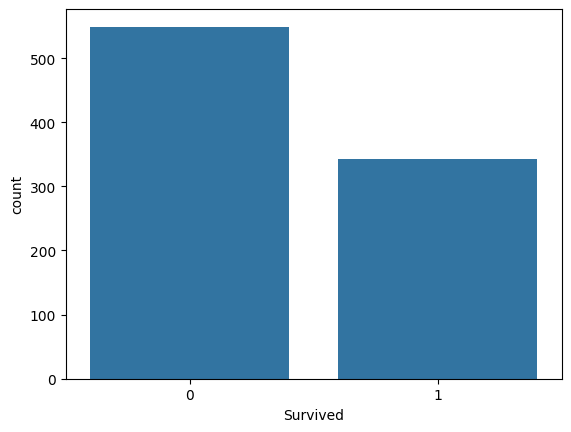

In [47]:
sns.countplot(x="Survived",data=dataframe_train)
plt.savefig('chart.png',dpi=300,bbox_inches='tight')
death=round(dataframe_train['Survived'].value_counts().values[0]/891*100)
print('out of 891 {}% people died '.format(death))

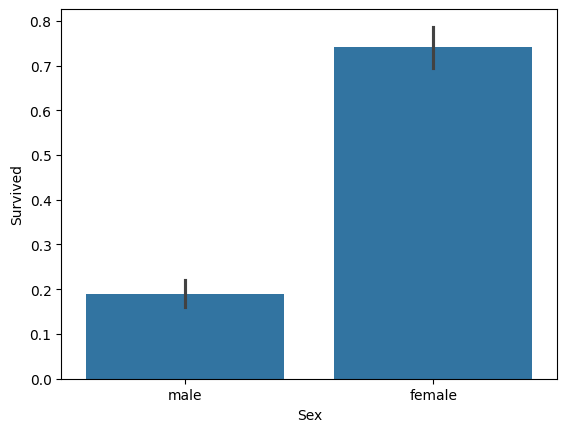

In [49]:
sns.barplot(x='Sex',y='Survived',data=dataframe_train)
plt.savefig('chart1.png',dpi=300,bbox_inches='tight')

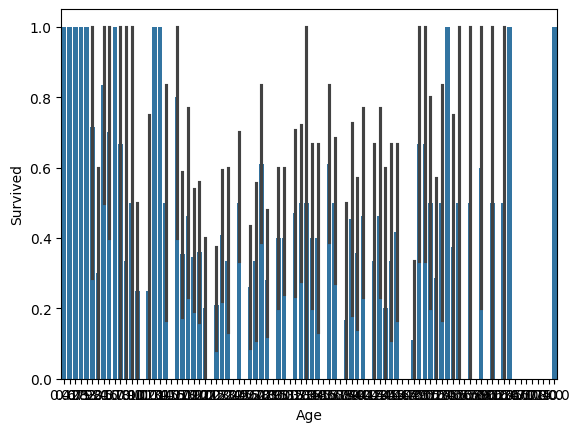

In [54]:
sns.barplot(x='Age',y='Survived',data=dataframe_train)
plt.savefig('chart2.png',dpi=300,bbox_inches='tight')

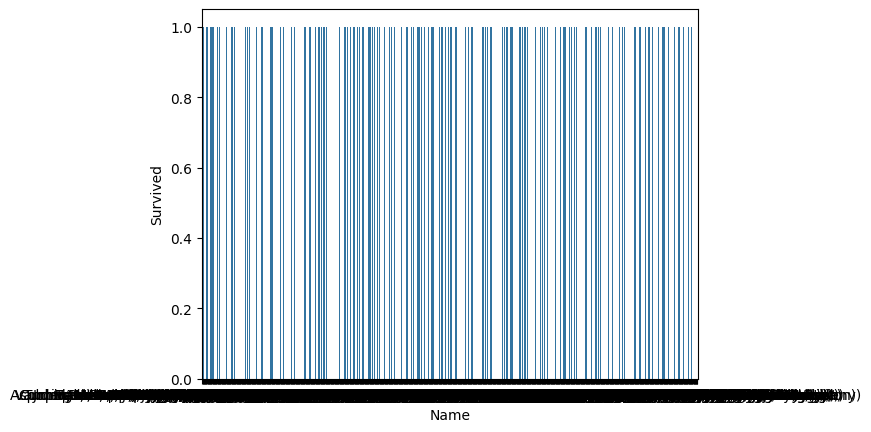

In [55]:
sns.barplot(x='Name',y='Survived',data=dataframe_train)
plt.savefig('chart3.png',dpi=300,bbox_inches='tight')

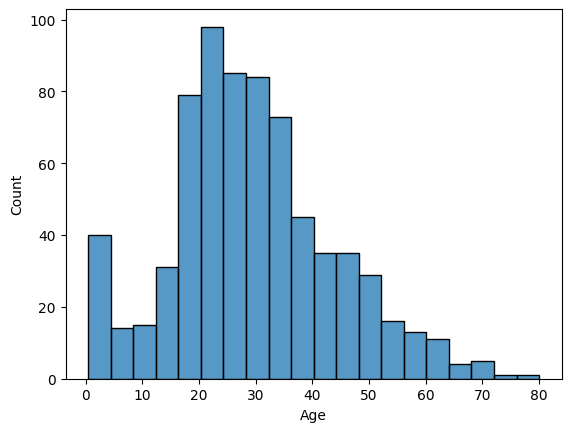

In [57]:
sns.histplot(x='Age',data=dataframe_train)
plt.savefig('chart5.png',dpi=300,bbox_inches='tight')

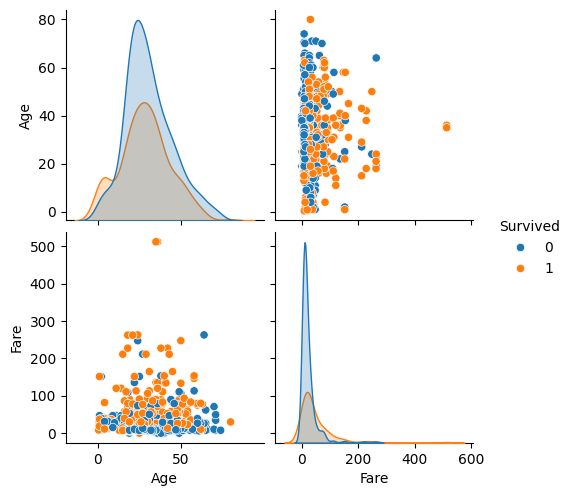

In [58]:
sns.pairplot(dataframe_train[["Age","Sex","Fare","Survived"]],hue="Survived")

In [59]:
dataframe_train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [61]:
data_one_hot=pd.get_dummies(dataframe_train,columns=['Sex'])
data_one_hot

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_female,Sex_male
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,S,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,C,True,False
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,True,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,S,True,False
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,S,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",27.0,0,0,211536,13.0000,NaN,S,False,True
887,888,1,1,"Graham, Miss. Margaret Edith",19.0,0,0,112053,30.0000,B42,S,True,False
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",NaN,1,2,W./C. 6607,23.4500,NaN,S,True,False
889,890,1,1,"Behr, Mr. Karl Howell",26.0,0,0,111369,30.0000,C148,C,False,True


In [67]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler
age_scaler=StandardScaler()
fare_scaler=StandardScaler()
data_one_hot['Age']=age_scaler.fit_transform(data_one_hot[['Age']])
data_one_hot['Fare']=fare_scaler.fit_transform(data_one_hot[['Fare']])
data_one_hot

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_female,Sex_male
0,1,0,3,"Braund, Mr. Owen Harris",-0.530377,1,0,A/5 21171,-0.502445,NaN,S,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0.571831,1,0,PC 17599,0.786845,C85,C,True,False
2,3,1,3,"Heikkinen, Miss. Laina",-0.254825,0,0,STON/O2. 3101282,-0.488854,NaN,S,True,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.365167,1,0,113803,0.420730,C123,S,True,False
4,5,0,3,"Allen, Mr. William Henry",0.365167,0,0,373450,-0.486337,NaN,S,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",-0.185937,0,0,211536,-0.386671,NaN,S,False,True
887,888,1,1,"Graham, Miss. Margaret Edith",-0.737041,0,0,112053,-0.044381,B42,S,True,False
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",NaN,1,2,W./C. 6607,-0.176263,NaN,S,True,False
889,890,1,1,"Behr, Mr. Karl Howell",-0.254825,0,0,111369,-0.044381,C148,C,False,True


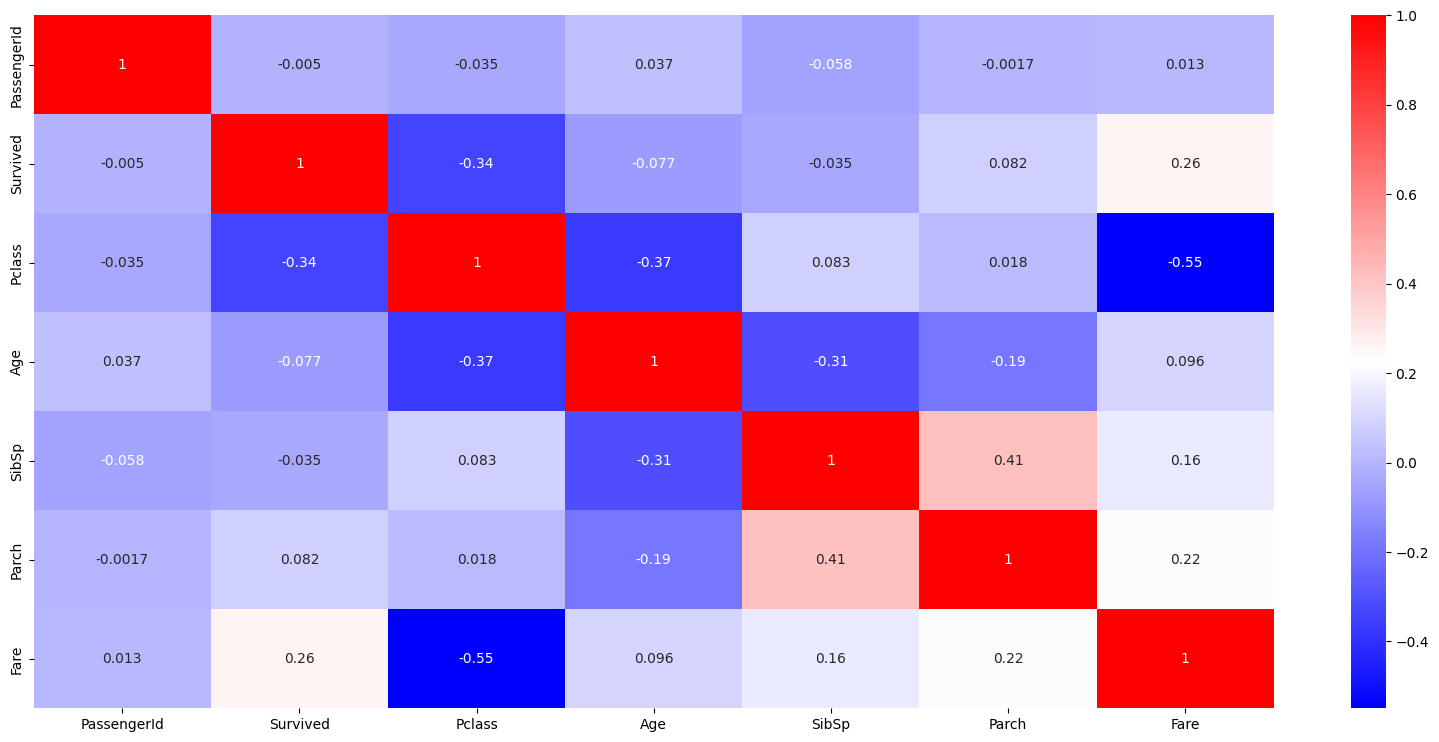

In [69]:
plt.figure(figsize=(20,9))
corr=data_one_hot.select_dtypes(include='number').corr()
sns.heatmap(corr,annot=True,cmap='bwr')
plt.savefig('chart6.png',dpi=300,bbox_inches='tight')
plt.show()